In [2]:
import os, zipfile
from pathlib import Path

zip_path = Path("minhash.zip")
assert zip_path.exists(), "minhash.zip not found. Upload it in Colab (Files -> Upload) and rerun."

work_dir = Path("work")
work_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(work_dir)

candidates = list(work_dir.rglob("minhash"))
assert candidates, "Could not find a folder named 'minhash' after unzipping."
minhash_dir = candidates[0]

needed = ["D1.txt", "D2.txt", "D3.txt", "D4.txt"]
present = {p.name for p in minhash_dir.glob("*.txt")}

print("minhash_dir =", minhash_dir)
print("txt files found:", sorted(present))

missing = [f for f in needed if f not in present]
assert not missing, f"Missing files: {missing}. Check zip contents / folder structure."

for f in needed:
    text = (minhash_dir / f).read_text(encoding="utf-8", errors="ignore")
    print("\n" + "="*60)
    print(f"{f} length={len(text)}")
    print(text[:200].replace("\n","\\n"))

minhash_dir = work/minhash
txt files found: ['D1.txt', 'D2.txt', 'D3.txt', 'D4.txt']

D1.txt length=1749
apple ceo tim cook is spending some time in canada this week and yesterday he attended a hockey game and visited the eaton centre apple store in toronto cook today stopped by the offices of canadian e

D2.txt length=1747
apple ceo tim cook is spending some time in canada this week and yesterday attended a hockey game and visited the eaton centre apple store in toronto tim cook today stopped by the offices of canadian 

D3.txt length=2132
as part of his one day tour of canada yesterday tim cook offered an interview to the financial post following his visit to ecommerce platform shopifys headquarters cook used the interview as an opport

D4.txt length=1435
president trump who warned as a candidate about the false song of globalism is marching straight into the maw of the global beast this week and he is singing his own tune trump is attending the global


In this step, I computed the shingles (k-grams) for each document.
Three types of shingles are generated:

*  2-character shingles
* 3-character shingles
* 2-word shingles


These shingles convert documents into sets of tokens.

We then compute exact Jaccard similarity between all document pairs:

𝐽
(
𝐴
,
𝐵
)
=
∣
𝐴
∩
𝐵
∣
∣
𝐴
∪
𝐵
∣
J(A,B)=
∣A∪B∣
∣A∩B∣
	​


This gives the true similarity between documents which will later be compared with MinHash approximation.

Generating Shingles + Exact Jaccard similarity

In [3]:
#Generate shingles and compute Jaccard similarity

import itertools
import re
from pathlib import Path

# Load documents
docs = {}
files = ["D1.txt","D2.txt","D3.txt","D4.txt"]

for f in files:
    text = (minhash_dir / f).read_text(encoding="utf-8", errors="ignore")

    # normalizing the text
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)

    docs[f] = text

print("Loaded documents:")
for k,v in docs.items():
    print(k,"length:",len(v))


# Shingle functions
def char_shingles(text, k):
    return {text[i:i+k] for i in range(len(text)-k+1)}

def word_shingles(text, k):
    words = text.split()
    return {" ".join(words[i:i+k]) for i in range(len(words)-k+1)}

#  Making shingles
shingles_2char = {}
shingles_3char = {}
shingles_2word = {}

for name,text in docs.items():

    shingles_2char[name] = char_shingles(text,2)
    shingles_3char[name] = char_shingles(text,3)
    shingles_2word[name] = word_shingles(text,2)

print("\nExample shingles from D1:")
print(list(shingles_2char["D1.txt"])[:10])


#  Jaccard function
def jaccard(a,b):
    return len(a & b) / len(a | b)


#  Finding similarities
pairs = list(itertools.combinations(files,2))

print("\n===== JACCARD SIMILARITY =====\n")

for p in pairs:

    d1,d2 = p

    j2 = jaccard(shingles_2char[d1],shingles_2char[d2])
    j3 = jaccard(shingles_3char[d1],shingles_3char[d2])
    jw = jaccard(shingles_2word[d1],shingles_2word[d2])

    print(f"{d1} vs {d2}")
    print(" 2-char :",round(j2,4))
    print(" 3-char :",round(j3,4))
    print(" 2-word :",round(jw,4))
    print()

Loaded documents:
D1.txt length: 1749
D2.txt length: 1747
D3.txt length: 2132
D4.txt length: 1435

Example shingles from D1:
['dw', 'em', 'ps', 'lt', 'er', 'n ', 'to', 'ut', 'op', 'fu']

===== JACCARD SIMILARITY =====

D1.txt vs D2.txt
 2-char : 0.9811
 3-char : 0.978
 2-word : 0.9408

D1.txt vs D3.txt
 2-char : 0.8157
 3-char : 0.5804
 2-word : 0.1823

D1.txt vs D4.txt
 2-char : 0.6444
 3-char : 0.3051
 2-word : 0.0302

D2.txt vs D3.txt
 2-char : 0.8
 3-char : 0.568
 2-word : 0.1737

D2.txt vs D4.txt
 2-char : 0.6413
 3-char : 0.3059
 2-word : 0.0303

D3.txt vs D4.txt
 2-char : 0.653
 3-char : 0.3121
 2-word : 0.0161



In [4]:
# Requirements: m > 10000 (we use m=20011), stable shingle->id mapping, random hash family.

import time
import random
import hashlib
import math


assert "shingles_3char" in globals(), "Run STEP 2 first (it creates shingles_3char)."

A = shingles_3char["D1.txt"]
B = shingles_3char["D2.txt"]

def stable_shingle_id(s: str) -> int:

    return int(hashlib.md5(s.encode("utf-8")).hexdigest(), 16)


A_ids = [stable_shingle_id(x) for x in A]
B_ids = [stable_shingle_id(x) for x in B]


true_j = len(A & B) / len(A | B)


m = 20011
p = 2147483647
def make_hash_funcs(t, seed=42):
    rnd = random.Random(seed)
    funcs = []
    for _ in range(t):
        a = rnd.randrange(1, p-1)
        b = rnd.randrange(0, p-1)
        funcs.append((a,b))
    return funcs

def minhash_signature(shingle_ids, hash_funcs):
    sig = []
    for a,b in hash_funcs:
        mn = None
        for x in shingle_ids:
            hx = ((a * x + b) % p) % m
            if mn is None or hx < mn:
                mn = hx
        sig.append(mn)
    return sig

def approx_jaccard(sig1, sig2):
    matches = sum(1 for i in range(len(sig1)) if sig1[i] == sig2[i])
    return matches / len(sig1)

t_values = [20, 60, 150, 300, 600]
results = []

print("TRUE Jaccard (3-grams) D1 vs D2 =", round(true_j, 4))
print("\nMinHash Approx Jaccard values:\n")

for t in t_values:
    start = time.time()
    H = make_hash_funcs(t, seed=123)
    sigA = minhash_signature(A_ids, H)
    sigB = minhash_signature(B_ids, H)
    jhat = approx_jaccard(sigA, sigB)
    elapsed = time.time() - start

    results.append((t, jhat, elapsed))
    print(f"t={t:3d}  J_hat={jhat:.4f}   time={elapsed:.4f} sec")


minhash_D1D2_results = results

TRUE Jaccard (3-grams) D1 vs D2 = 0.978

MinHash Approx Jaccard values:

t= 20  J_hat=1.0000   time=0.0117 sec
t= 60  J_hat=0.9667   time=0.0358 sec
t=150  J_hat=0.9800   time=0.0867 sec
t=300  J_hat=0.9633   time=0.1783 sec
t=600  J_hat=0.9700   time=0.3465 sec


In [5]:
#Jaccard similarity table for all pairs and all shingle types

import pandas as pd
import itertools

docs = ["D1.txt","D2.txt","D3.txt","D4.txt"]

rows = []

for d1,d2 in itertools.combinations(docs,2):

    j2 = jaccard(shingles_2char[d1],shingles_2char[d2])
    j3 = jaccard(shingles_3char[d1],shingles_3char[d2])
    jw = jaccard(shingles_2word[d1],shingles_2word[d2])

    rows.append({
        "Doc Pair": f"{d1}-{d2}",
        "2-char Jaccard": round(j2,4),
        "3-char Jaccard": round(j3,4),
        "2-word Jaccard": round(jw,4)
    })

df_jaccard = pd.DataFrame(rows)

print("\nJaccard Similarity Table\n")
display(df_jaccard)


Jaccard Similarity Table



,Doc Pair,2-char Jaccard,3-char Jaccard,2-word Jaccard
0,D1.txt-D2.txt,0.9811,0.9780,0.9408
1,D1.txt-D3.txt,0.8157,0.5804,0.1823
2,D1.txt-D4.txt,0.6444,0.3051,0.0302
3,D2.txt-D3.txt,0.8000,0.5680,0.1737
4,D2.txt-D4.txt,0.6413,0.3059,0.0303
5,D3.txt-D4.txt,0.6530,0.3121,0.0161


LSH

In [6]:
# Locality Sensitive Hashing (LSH) on MinHash signatures

import hashlib
from collections import defaultdict

# We will use t = 100 hash functions for LS
t = 100
bands = 20
rows = t // bands

print("Bands:",bands," Rows per band:",rows)

H = make_hash_funcs(t, seed=999)

signatures = {}

for doc in files:
    ids = [stable_shingle_id(x) for x in shingles_3char[doc]]
    signatures[doc] = minhash_signature(ids,H)

print("\nMinHash signatures generated.")


buckets = defaultdict(list)

for doc,sig in signatures.items():

    for b in range(bands):

        start = b*rows
        end = start+rows

        band = tuple(sig[start:end])

        bucket_id = hashlib.md5(str(band).encode()).hexdigest()

        buckets[(b,bucket_id)].append(doc)


candidates = set()

for bucket_docs in buckets.values():

    if len(bucket_docs) > 1:

        for i in range(len(bucket_docs)):
            for j in range(i+1,len(bucket_docs)):

                pair = tuple(sorted((bucket_docs[i],bucket_docs[j])))
                candidates.add(pair)

print("\nCandidate similar document pairs detected by LSH:\n")

for pair in candidates:
    print(pair)

Bands: 20  Rows per band: 5

MinHash signatures generated.

Candidate similar document pairs detected by LSH:

('D2.txt', 'D4.txt')
('D1.txt', 'D2.txt')
('D1.txt', 'D4.txt')


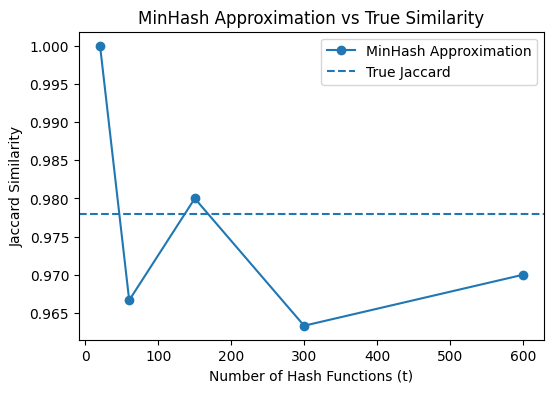

In [7]:
#Plotting MinHash approximation vs number of hash functions

import matplotlib.pyplot as plt

t_vals = [r[0] for r in minhash_D1D2_results]
approx_vals = [r[1] for r in minhash_D1D2_results]

plt.figure(figsize=(6,4))
plt.plot(t_vals, approx_vals, marker='o', label="MinHash Approximation")

plt.axhline(true_j, linestyle='--', label="True Jaccard")

plt.xlabel("Number of Hash Functions (t)")
plt.ylabel("Jaccard Similarity")
plt.title("MinHash Approximation vs True Similarity")
plt.legend()

plt.show()

In [8]:
#Runtime summary

import pandas as pd

runtime_df = pd.DataFrame(minhash_D1D2_results,
                          columns=["Hash Functions (t)","Approx Jaccard","Runtime (seconds)"])

display(runtime_df)

,Hash Functions (t),Approx Jaccard,Runtime (seconds)
0,20,1.000000,0.011653
1,60,0.966667,0.035841
2,150,0.980000,0.086676
3,300,0.963333,0.178328
4,600,0.970000,0.346486
